# Data structure of a (pandapower) network

This notebook shows the data structure behind a generated LV grid: its buses, lines, transformer and loads as pandapower tables. The map plots download basemap tiles from OpenStreetMap (internet access needed).

**Prerequisites**

- pylovo installed with the `notebooks` extra (`uv sync --extra notebooks`) and this notebook running on the kernel of the project environment (`.venv`), see `notebook_tutorials/README.md`.
- A `.env` in the repository root that points to your pylovo database, a completed `pylovo-setup` and generated grids for the postcode area (PLZ) below, e.g. `pylovo-generate --plz 85653`.
- Grids are read for the `VERSION_ID` of `config/config_generation.yaml`.

The stored outputs were generated for the demo postcode area 85653 (Aying), whose buildings, streets and transformers are derived from OpenStreetMap. Map data © OpenStreetMap contributors (ODbL).

In [1]:
# Parameters
plz = 85653  # postcode area with generated grids
kcid = None  # k-means cluster id of the grid; None: first grid of the PLZ
bcid = None  # building cluster id of the grid; None: first grid of the PLZ

## Setup

In [2]:
import warnings

import pandas as pd
import plotly.io as pio

from pylovo.config_loader import VERSION_ID
from pylovo.database.database_client import DatabaseClient
from pylovo.plotting.generation.networks import plot_contextily, plot_grid_on_map, plot_simple_grid
from pylovo.plotting.gis_preparation.io_geodata import get_bus_line_geo_for_network

warnings.filterwarnings("ignore")
# pandapower's plotly functions select the "notebook" renderer, which embeds the complete
# plotly.js (about 4.7 MB) for every figure. The CDN variant keeps this notebook small.
pio.renderers["notebook"] = pio.renderers["notebook_connected"]


In [3]:
dbc = DatabaseClient()  # read-only access (GridGenerator is only needed to generate grids)
cluster_list = dbc.get_list_from_plz(plz)
if not cluster_list:
    raise ValueError(f"No grids of version {VERSION_ID} for PLZ {plz}. Run: pylovo-generate --plz {plz}")
if kcid is None or bcid is None:
    kcid, bcid = cluster_list[0]
print(f"PLZ {plz}, version {VERSION_ID}: {len(cluster_list)} grids; selected kcid={kcid}, bcid={bcid}")

PLZ 85653, version 1: 4 grids; selected kcid=1, bcid=1


## Recall
The grid on a map, as built up in `1_map_visualization_examples.ipynb`.

*Map data © OpenStreetMap contributors (ODbL).*

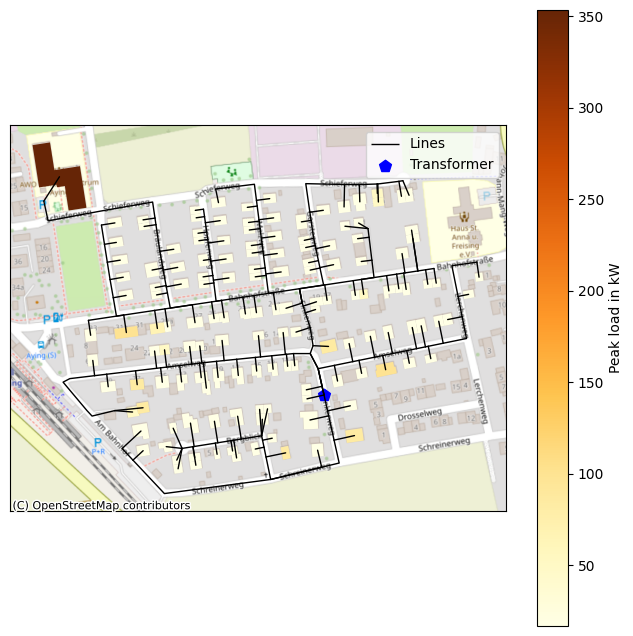

In [4]:
plot_contextily(plz=plz, kcid=kcid, bcid=bcid, zoomfactor=17);

## Interactive pandapower plots
The generated LV grids are stored in the database as pandapower networks (column `grid` of `grid_result`; the element tables are also stored in the `pandapower_*` tables). See the pandapower documentation: https://pandapower.readthedocs.io/en/latest/index.html

Hover over the following plot to find out more about the components.

In [5]:
plot_simple_grid(plz=plz, kcid=kcid, bcid=bcid)

There are different kinds of buses:
- Consumer Nodebus: house connection. Each consumer has one or more loads that define its power demand.
- Connection Nodebus: connection point on the street, e.g. where a house connection branches off or the cable type changes.
- MVbus: connection to the MV grid (external grid).
- LVbus: LV side of the transformer.

Lines are cables of different types with different properties such as resistance, reactance and maximum current.

The network can also be plotted on an OpenStreetMap background. Zoom with the mouse wheel.

*Map data © OpenStreetMap contributors (ODbL).*

In [6]:
fig = plot_grid_on_map(plz=plz, kcid=kcid, bcid=bcid)

## Pandapower network properties
The properties of the network shown above:

In [7]:
net = dbc.read_net_db(plz=plz, kcid=kcid, bcid=bcid)
net

This pandapower network includes the following parameter tables:
   - bus (283 elements)
   - load (144 elements)
   - ext_grid (1 element)
   - line (281 elements)
   - trafo (1 element)
 and the following results tables:
   - res_bus (283 elements)
   - res_line (281 elements)
   - res_trafo (1 element)
   - res_ext_grid (1 element)
   - res_load (144 elements)

Each table can be retrieved as a pandas DataFrame with `net.<table>`, e.g. the transformer:

In [8]:
net.trafo

,name,std_type,hv_bus,lv_bus,sn_mva,vn_hv_kv,vn_lv_kv,vk_percent,vkr_percent,pfe_kw,...,tap_step_degree,tap_pos,tap_changer_type,id_characteristic_table,tap_dependency_table,parallel,df,in_service,vector_group,oltc
0,single 400 kva transformer,0.4 MVA 20/0.4 kV,1,0,0.4,20.0,0.4,6.0,1.425,1.35,...,0.0,0.0,Ratio,<NA>,False,1,1.0,True,Dyn5,False


`sn_mva` is the rating of one transformer unit and `parallel` the number of units; a station with two parallel 400 kVA units has `sn_mva = 0.4` and `parallel = 2`.

The buses with their coordinates (GeoJSON in WGS84, column `geo`). For consumer buses the column `zone` holds the consumer category of the building:

In [9]:
net.bus.head()

,name,vn_kv,type,zone,in_service,geo,min_vm_pu,max_vm_pu
0,LVbus 1,0.4,n,n,True,"{""coordinates"":[11.773804221522283,47.96867261...",0.9,1.1
1,MVbus 1,20.0,n,n,True,"{""coordinates"":[11.773804221522283,47.96882261...",0.9,1.1
2,Connection Nodebus 377,0.4,n,n,True,"{""coordinates"":[11.773804221522283,47.96867261...",0.9,1.1
3,Connection Nodebus 372,0.4,n,n,True,"{""coordinates"":[11.773780531608997,47.96875837...",0.9,1.1
4,Connection Nodebus 380,0.4,n,n,True,"{""coordinates"":[11.773847258420133,47.96851682...",0.9,1.1


The loads: `p_mw`/`q_mvar` are the operating point used for the power flow, `max_p_mw` the installed peak load of the consumer, `load_units` the number of households (residential) or units and `category` the consumer category.

In [10]:
net.load.head()

,name,bus,p_mw,q_mvar,const_z_p_percent,const_i_p_percent,const_z_q_percent,const_i_q_percent,sn_mva,scaling,in_service,type,service_design_p_mw,operating_point_basis,category,load_units,consumer_vertex,max_p_mw
0,Load 97 Residential,139,0.030754,0.010108,0.0,0.0,0.0,0.0,NaN,1.0,True,wye,0.058229,synthetic_transformer_coincident_proportional,Residential,21.0,97.0,0.353325
1,Load 111 Residential,140,0.001464,0.000481,0.0,0.0,0.0,0.0,NaN,1.0,True,wye,0.016825,synthetic_transformer_coincident_proportional,Residential,1.0,111.0,0.016825
2,Load 114 Residential,141,0.001464,0.000481,0.0,0.0,0.0,0.0,NaN,1.0,True,wye,0.016825,synthetic_transformer_coincident_proportional,Residential,1.0,114.0,0.016825
3,Load 124 Residential,142,0.001464,0.000481,0.0,0.0,0.0,0.0,NaN,1.0,True,wye,0.016825,synthetic_transformer_coincident_proportional,Residential,1.0,124.0,0.016825
4,Load 130 Residential,143,0.001464,0.000481,0.0,0.0,0.0,0.0,NaN,1.0,True,wye,0.016825,synthetic_transformer_coincident_proportional,Residential,1.0,130.0,0.016825


The consumer buses:

In [11]:
consumer_buses = net.bus[net.bus["name"].str.contains("Consumer Nodebus")]
consumer_buses.head()

,name,vn_kv,type,zone,in_service,geo,min_vm_pu,max_vm_pu
139,Consumer Nodebus 97,0.4,n,Residential,True,"{""coordinates"":[11.770077305595109,47.97089341...",0.9,1.1
140,Consumer Nodebus 111,0.4,n,Residential,True,"{""coordinates"":[11.770447538249005,47.96933704...",0.9,1.1
141,Consumer Nodebus 114,0.4,n,Residential,True,"{""coordinates"":[11.770465545159167,47.96909092...",0.9,1.1
142,Consumer Nodebus 124,0.4,n,Residential,True,"{""coordinates"":[11.770675704396611,47.96882919...",0.9,1.1
143,Consumer Nodebus 130,0.4,n,Residential,True,"{""coordinates"":[11.770858376942423,47.97042414...",0.9,1.1


Consumer categories of the buses. They are defined in `CONSUMER_CATEGORIES` of `config/config_generation.yaml` (residential, commercial, public; `Mixed` for buildings with residential and non-residential use).

In [12]:
consumer_buses["zone"].value_counts()

zone
Residential    144
Name: count, dtype: int64

Power flow results are stored with the network, e.g. the bus voltages:

In [13]:
pd.concat([net.bus["name"], net.res_bus[["vm_pu", "p_mw"]]], axis=1).head()

,name,vm_pu,p_mw
0,LVbus 1,0.972163,0.000000
1,MVbus 1,1.000000,-0.316946
2,Connection Nodebus 377,0.972023,0.000000
3,Connection Nodebus 372,0.969831,0.000000
4,Connection Nodebus 380,0.970907,0.000000


The line geometries as a GeoDataFrame:

In [14]:
line_gdf, bus_gdf = get_bus_line_geo_for_network(net, plz)
line_gdf = line_gdf.set_crs("EPSG:4326")
line_gdf[["name", "std_type", "length_km", "parallel", "geometry"]].head()

,name,std_type,length_km,parallel,geometry
0,Line to 94,NAYY_4_150,0.154911,1,"LINESTRING (11.77144 47.97046, 11.77142 47.970..."
1,Line to 153,NAYY_4_150,0.007250,1,"LINESTRING (11.77145 47.97039, 11.77144 47.97046)"
2,Line to 155,NAYY_4_150,0.029200,1,"LINESTRING (11.7715 47.97013, 11.77145 47.97039)"
3,Line to 160,NAYY_4_150,0.018425,1,"LINESTRING (11.77153 47.96997, 11.7715 47.97013)"
4,Line to 164,NAYY_4_150,0.002251,1,"LINESTRING (11.77153 47.96995, 11.77153 47.96997)"


Next notebook: `2_1_pandapower_networks_generic_coord.ipynb` plots the grid with generic (topology-based) coordinates.